# 베이즈의 정리

In [ ]:
P_A = 0.1 # 암의 확률
P_not_A = 1 - P_A # 암이 아닐 확률
P_B_given_A = 0.95 # 양성판정의 정확도
P_B_given_not_A = 0.05 # 암이 아닌데 양성판정

# 베이즈의 정리
P_A_given_B = P_B_given_A * P_A / ((P_B_given_A*P_A)+(P_B_given_not_A*P_not_A)) # 괄호 = P_B
P_A_given_B

0.6785714285714285

# 확률의 계산 

## 동전던지기 

In [4]:
space = ['앞면', '뒷면']
event = ['앞면']

prob = lambda event, space : len(event) / len(space)
prob(event, space)

0.5

In [5]:
# 주사위 던지기
# 1번 던져서 3이 나올 확률
space = [1,2,3,4,5,6]
event = [3]
prob(event , space)

0.16666666666666666

# 확률의 덧셈

## 주사위에서 짝수이거나 4보다 큰 수가 나올 확률

In [7]:
space = {1,2,3,4,5,6}
event_a = {2,4,6}
event_b = {5,6}


In [8]:
합집합 = event_a | event_b
합집합

{2, 4, 5, 6}

In [10]:
합집합의갯수 = len(합집합)
전체경우의수 = len(space)
확률_1 = 합집합의갯수/전체경우의수
확률_1

0.6666666666666666

## 2이하이거나 5이상인 눈이 나올 확률

In [13]:
event_a = {1,2}
event_b = {5,6}
합집합 = event_a | event_b
합집합의갯수 = len(합집합)
확률_1 = 합집합의갯수/전체경우의수
확률_1

0.6666666666666666

# 확률의 교집합

## 주사위를 던져 짝수이며 2일 확률

In [ ]:
# 조건부 확률
ev_a = [2,4,6]
ev_b = [2]
pa = len(ev_a)/len(space)
pb = len(ev_b)/len(space)
pba = ev_a and ev_b # 교집합의 원소
p_b_and_a = len(pba) / len(space) # 교집합이 나올 확률
p_b_and_a

0.16666666666666666

In [18]:
# 조건부 확률: 짝수일때 2가 나올 확률
# p(b|a) = p(b_and_a)/pa
p_b_given_a  = p_b_and_a / pa
p_b_given_a

0.3333333333333333

# 우도와 확률값

동전 10번 던지고 8번 앞면이 나왔다  
우도의 계산

In [19]:
from scipy.stats import binom

In [20]:
n = 10
k = 8 # 앞면의 횟수

# 가설1 - 공정한 동전일 것이다
p1 = 0.5 # 앞면이 나올 확률 - 공정할 경우
p1 = 0.5 # 앞면이 나올 확률 - 공정할 경우
p1_likelihood =  binom.pmf(k,n,p1) # 조건, 총사건, 확률 =  binom.pmf(k,n,p1) # 조건, 총사건, 확률

p2 = 0.8
p2_likelihood =  binom.pmf(k,n,p2) # 조건, 총사건, 확률

p1_likelihood, p2_likelihood

(np.float64(0.04394531250000005), np.float64(0.30198988799999993))

가설1의 경우, 앞면이 8번 나올확률은 4.4%    
가설2의 경우 앞면이 8번 나올확률은 30.2%    

앞면만 8번 나오는 관측값은 p = 0.8인 모델이 더 잘 설명한다 (우도가 더 크다)

# 기대값
x의 확률들의 평균

In [22]:
x_values = [1,2,3]
p_x = [1/6, 3/6, 2/6 ]
exp_value = 0
# 기대값
for i in range(len(x_values)):
    exp_value += x_values[i] * p_x[i]
print(f'기대값 : {exp_value:.5f}')

기대값 : 2.16667


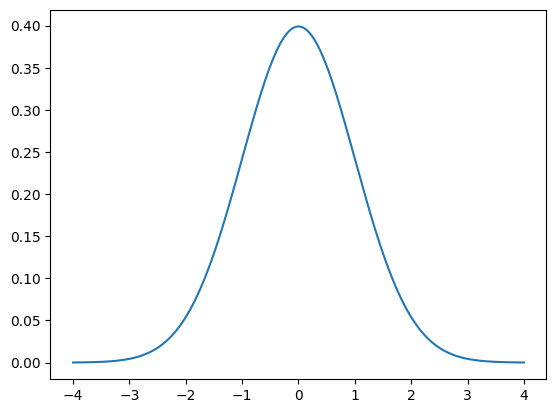

In [28]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

mu = 0
sigma = 1
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, loc=mu, scale = sigma)
plt.plot(x,y)
plt.show()

# 표집분포

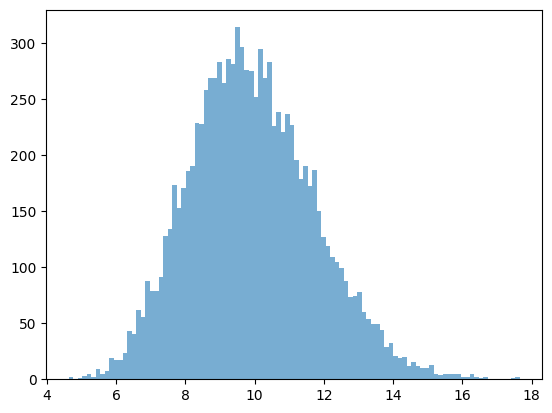

In [32]:
np.random.seed(0)
X_pop = np.random.exponential(scale = 10, size = 10000)
sample_mean = [np.mean(np.random.choice(X_pop, size = 30))
               for _ in range(10000)]
plt.hist(sample_mean, bins= 100, alpha = 0.6)
plt.show()

# z점수 

In [33]:
mu = 100
sigma = 10

x1 = 110 # z점수를 계산하려고 하는 원래 점수
x2 = 125

# z점수 = 원점수 - 평균 / 표준편차
z_x1 = (x1-mu)/sigma
z_x2 = (x2-mu)/sigma
z_x1,z_x2

(1.0, 2.5)

## 정규분포표 확인
z_x1 = 0.8413 -> 0.5 -> 0.3413  
z_x2 = 0.9938 -> 0.5 -> 0.4938

0.4938 - 0.3413 = 0.1525 : 15%

전체 분포에서 x1~x2 사이의 면적

In [34]:
area_z_x1 = norm.cdf(z_x1) - norm.cdf(0)
area_z_x2 = norm.cdf(z_x2) - norm.cdf(0)
diff = area_z_x2 - area_z_x1
diff

np.float64(0.15244558860568092)

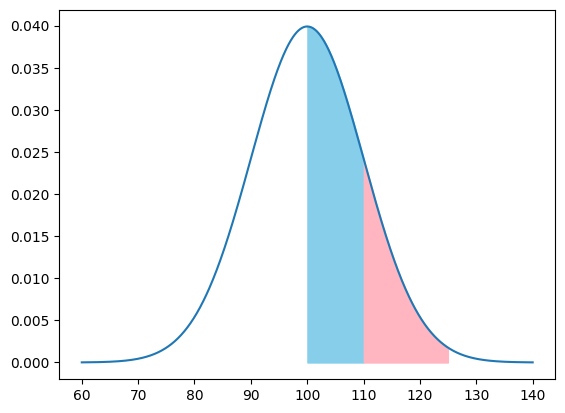

In [41]:
# 시각화 
x = np.linspace(mu-4*sigma, mu+4*sigma, 1000)
y = norm.pdf(x,mu, sigma)
plt.plot(x,y)
plt.fill_between(x,y, where=(x>=100)&(x<=110), color='skyblue')
plt.fill_between(x,y, where=(x>110)&(x<=125), color='lightpink')